<a href="https://colab.research.google.com/github/Abdukamol0870/Avtomobil/blob/main/k_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [231]:
url = "https://raw.githubusercontent.com/AhmadaliyevB/DAtalar/refs/heads/main/diabetes.csv"
df = pd.read_csv(url)
df.sample(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
232,1,79,80,25,37,25.4,0.583,22,0
573,2,98,60,17,120,34.7,0.198,22,0
670,6,165,68,26,168,33.6,0.631,49,0
479,4,132,86,31,0,28.0,0.419,63,0
760,2,88,58,26,16,28.4,0.766,22,0
210,2,81,60,22,0,27.7,0.290,25,0
91,4,123,80,15,176,32.0,0.443,34,0
127,1,118,58,36,94,33.3,0.261,23,0
570,3,78,70,0,0,32.5,0.270,39,0
69,4,146,85,27,100,28.9,0.189,27,0


In [232]:
df['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


In [233]:
from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()
df['Outcome'] = labelencoder.fit_transform(df['Outcome'].values)
df['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


In [207]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [208]:
corr_matrix = df.corr().abs()
corr_matrix .style.background_gradient(cmap = 'coolwarm')

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,0.081672,0.073535,0.017683,0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,0.113970,0.074752
Insulin,0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,0.113970,0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


In [209]:
df.corrwith(df['Outcome']).abs().sort_values(ascending=False)

,0
Outcome,1.000000
Glucose,0.466581
BMI,0.292695
Age,0.238356
Pregnancies,0.221898
DiabetesPedigreeFunction,0.173844
Insulin,0.130548
SkinThickness,0.074752
BloodPressure,0.065068


In [210]:
#ML ga tayyorlaymiz
x = df.drop('Outcome', axis=1).values
y = df['Outcome']

In [211]:
#0 va 1 oralig'ida Standartlashtiramiz
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x = scaler.fit_transform(x)

In [246]:
# Train/test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=12)
#k-NN
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=17)  # k-ni qiymati
knn.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=17)

In [247]:
y_predict = knn.predict(x_test)

In [248]:
#Baholash Jaccard index
from sklearn.metrics import jaccard_score
jaccard_score(y_test, y_predict)

np.float64(0.5230769230769231)

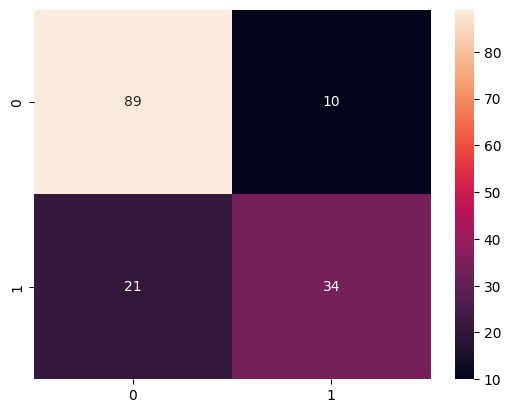

In [249]:
#Confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(confusion_matrix(y_test, y_predict), annot=True)
plt.show()

In [250]:
confusion_matrix(y_test, y_predict)

array([[89, 10],
       [21, 34]])

In [251]:
#Precision, recall, F1
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
precision = precision_score(y_test, y_predict)
recall = recall_score(y_test, y_predict)
f1 = f1_score(y_test, y_predict)
accuracy = accuracy_score(y_test, y_predict)
print(f'Precision: {precision}\nRecall: {recall}\nF1: {f1}\nAccuracy: {accuracy}')

Precision: 0.7727272727272727
Recall: 0.6181818181818182
F1: 0.6868686868686869
Accuracy: 0.7987012987012987


In [252]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.81      0.90      0.85        99
           1       0.77      0.62      0.69        55

    accuracy                           0.80       154
   macro avg       0.79      0.76      0.77       154
weighted avg       0.80      0.80      0.79       154



In [254]:
# Cross-validation yordamida tekshiramiz
#Cross validation
from sklearn.model_selection import cross_val_predict
predict = cross_val_predict(estimator = knn, X=x, y=y, cv = 5)
#Modelni baholash
from sklearn.metrics import classification_report
print(classification_report(y, predict))

              precision    recall  f1-score   support

           0       0.78      0.89      0.83       500
           1       0.72      0.54      0.62       268

    accuracy                           0.77       768
   macro avg       0.75      0.71      0.73       768
weighted avg       0.76      0.77      0.76       768



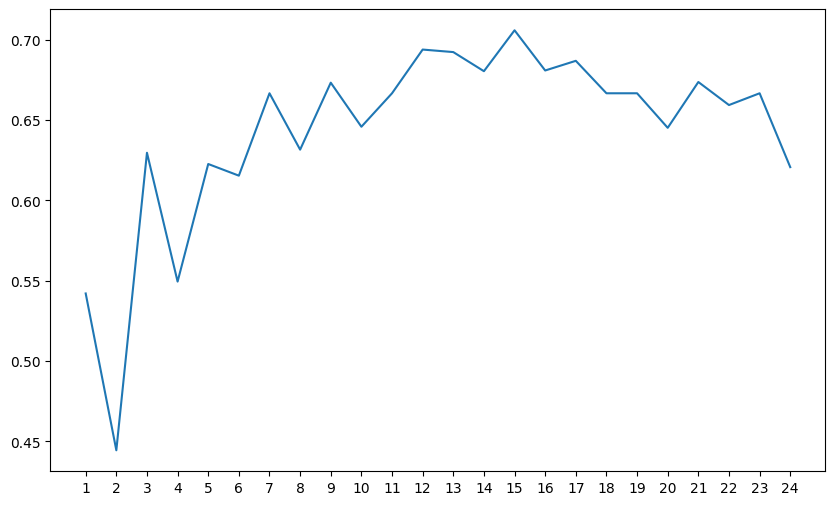

In [255]:
# Eng yaxshi k ni topish
f1 = []
for k in range(1, 25):
  knn =KNeighborsClassifier(n_neighbors=k)
  knn.fit(x_train, y_train)
  y_predict = knn.predict(x_test)
  f1.append(f1_score(y_test, y_predict))
plt.figure(figsize=(10,6))
plt.plot(range(1,25),f1)
plt.xticks(range(1,25))
plt.show()

In [256]:
from sklearn.model_selection import GridSearchCV
param_grid = {'n_neighbors': np.arange(1, 25)}
knn_gscv = GridSearchCV(knn, param_grid, cv=5)
knn_gscv.fit(x,y)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(n_neighbors=24),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24])})

In [257]:
knn_gscv.cv_results_['rank_test_score']

array([24, 23, 15, 18, 22, 21, 17, 16, 20, 19, 14,  9,  4, 11,  3, 12,  1,
        6,  2,  8,  5, 10,  7, 13], dtype=int32)

In [258]:
knn_gscv.best_params_

{'n_neighbors': np.int64(17)}

In [259]:
knn_gscv.best_score_

np.float64(0.7669892199303965)

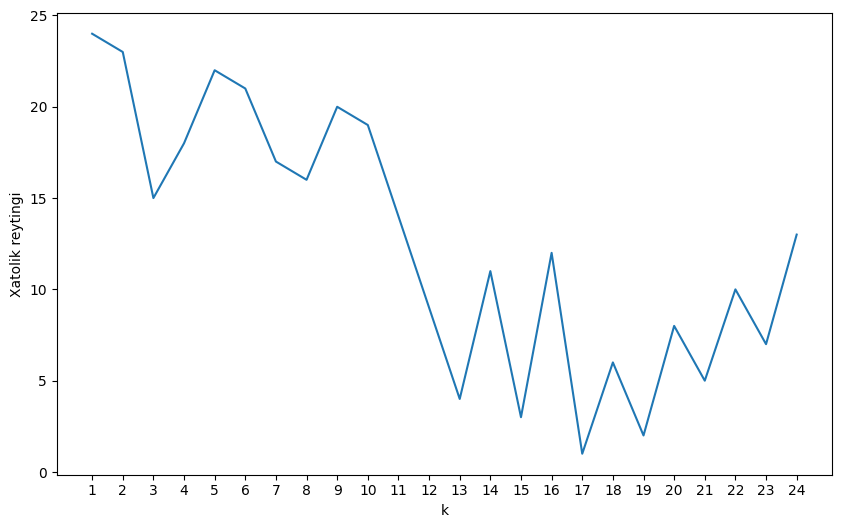

In [260]:
plt.figure(figsize=(10,6))
plt.plot(param_grid['n_neighbors'], knn_gscv.cv_results_['rank_test_score'])
plt.xticks(np.arange(1, 25))
plt.xlabel("k")
plt.ylabel("Xatolik reytingi")
plt.show()

Quyidagi ma'lumotlar to'plami Hindistonning Qandli diabet va buyrak kasalliklari milliy institutidan olingan. Maqsad diagnostik o'lchovlar asosida bemorda diabet bor-yo'qligini taxmin qilishdir.


Tarkib

Dataset ichida barcha bemorlar kamida 21 yoshli ayollari.





Ustunlar





Pregnancies: homilador bo'lish soni



Glucose: glyukozaga test natijasi



BloodPressure: diastolik qon bosimi (mm Hg)



SkinThickness: Triceps teri burmasining qalinligi (mm)



Insulin: 2 soatlik sarum insulini (mu U/ml)



BMI: Tana massasi indeksi (vazn kg / (m bo'yi) ^ 2)



DiabetesPedigreeFunction: diabetning naslchilik funktsiyasi



Age: Yosh (yil)



Outcome: Class (0 - diabet yo'q, 1 - diabet)

In [ ]:
https://raw.githubusercontent.com/AhmadaliyevB/DAtalar/refs/heads/main/diabetes.csv
